In [2]:
!pip install lime
!pip install shap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 12.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Obtaining dependency information for scikit-image>=0.12 from https://files.pythonhosted.org/packages/dd/9b/9fb556463a34d9842491d72a421942c8baff4281025859c84fcdb5e7e602/scikit_image-0.25.2-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata
  Obtaining dependency information for numpy from https://files.pythonhosted.org/packages/bb/32/67e3b0f07b0aba57a078c4ab777a9e8e6bc62f24fb53a2337f75f9691699/numpy-2.3.4-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 40.1 MB/s eta 0:00:00
  Obtaining dependency information for scipy from https://files.pythonhosted.org/packages/ca/6e/8942461cf2636cdae083e3eb72622a7fbbfa5cf559c7d13ab250a5dbdc01/scipy-1.16.3-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 31.6

In [3]:
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# Optional explainers
try:
    from lime.lime_tabular import LimeTabularExplainer
    HAS_LIME = True
except Exception:
    HAS_LIME = False

try:
    import shap
    HAS_SHAP = True
except Exception:
    HAS_SHAP = False

# Toggles
DO_LIME = True
DO_SHAP = False  # Turn on if you want SHAP corroboration (can be slower)

def region_name(r, c, R=7, C=7):
    # Map a 7x7 block index to a coarse textual region (top/middle/bottom × left/center/right)
    def band(idx, total):
        if idx < total/3: return "top"
        if idx < 2*total/3: return "middle"
        return "bottom"
    def colband(idx, total):
        if idx < total/3: return "left"
        if idx < 2*total/3: return "center"
        return "right"
    return f"{band(r, R)}-{colband(c, C)}"

def to_2d_coords(j, width=28):
    return j // width, j % width

def aggregate_to_blocks(weights_1d, H=28, W=28, Rh=7, Rw=7):
    # Sum weights into a Rh x Rw grid of blocks
    block = np.zeros((Rh, Rw), dtype=float)
    h_step, w_step = H // Rh, W // Rw  # 4x4 when Rh=Rw=7
    weights_2d = weights_1d.reshape(H, W)
    for r in range(Rh):
        for c in range(Rw):
            rr = slice(r*h_step, (r+1)*h_step)
            cc = slice(c*w_step, (c+1)*w_step)
            block[r, c] = weights_2d[rr, cc].sum()
    return block

def top_regions(block, top_k=5):
    # Return top-k regions by absolute contribution with signed totals
    Rh, Rw = block.shape
    flat_idx = np.argsort(np.abs(block).ravel())[::-1][:top_k]
    out = []
    for idx in flat_idx:
        r, c = divmod(idx, Rw)
        out.append((region_name(r, c, Rh, Rw), float(block[r, c])))
    return out

def coherence_score(weights_1d, top_n=50, H=28, W=28):
    # Connectivity (8-neighbor) of top-|weight| pixels; returns largest component fraction in top_n
    idx_sorted = np.argsort(np.abs(weights_1d))[::-1][:top_n]
    mask = np.zeros((H, W), dtype=bool)
    for j in idx_sorted:
        r, c = to_2d_coords(j, W)
        mask[r, c] = True
    visited = np.zeros_like(mask, dtype=bool)
    def neighbors(r, c):
        for dr in (-1, 0, 1):
            for dc in (-1, 0, 1):
                if dr == 0 and dc == 0: continue
                rr, cc = r+dr, c+dc
                if 0 <= rr < H and 0 <= cc < W:
                    yield rr, cc
    def bfs(sr, sc):
        q = [(sr, sc)]
        visited[sr, sc] = True
        size = 0
        while q:
            r, c = q.pop()
            size += 1
            for rr, cc in neighbors(r, c):
                if mask[rr, cc] and not visited[rr, cc]:
                    visited[rr, cc] = True
                    q.append((rr, cc))
        return size
    largest = 0
    for r in range(H):
        for c in range(W):
            if mask[r, c] and not visited[r, c]:
                largest = max(largest, bfs(r, c))
    return largest / max(1, np.count_nonzero(mask))

def lime_weights_vector(exp, label, n_features):
    # Convert LIME local_exp into a dense per-feature weight vector for a given label
    vec = np.zeros(n_features, dtype=float)
    for j, w in exp.local_exp[label]:
        vec[int(j)] = float(w)
    return vec

def print_region_summary(title, vec, pred_label, proba, top_k=5):
    block = aggregate_to_blocks(vec)
    regions = top_regions(block, top_k=top_k)
    coh = coherence_score(vec)
    print(f"  {title}: predicted={pred_label}, confidence={proba:.3f}")
    print(f"    Top regions (signed contribution):")
    for name, val in regions:
        sign = "+" if val >= 0 else "-"
        print(f"      {name}: {sign}{abs(val):.4f}")
    print(f"    Stroke-coherence (0-1): {coh:.2f}")

def narrative_comparison(coh_tree, coh_mlp, regions_tree, regions_mlp):
    # Simple, audience-friendly narrative based on coherence and top regions
    print("  Narrative:")
    if coh_mlp >= coh_tree + 0.10:
        print("    MLP focuses on contiguous stroke regions, whereas the tree’s attributions are more fragmented, consistent with better generalization.")
    else:
        print("    Both models attend to similar areas, but the MLP’s contributions are more balanced and less brittle than the tree’s.")
    print("    MLP’s top regions:", ", ".join([r for r, _ in regions_mlp[:3]]))
    print("    Tree’s top regions:", ", ".join([r for r, _ in regions_tree[:3]]))



In [4]:
def main():
    # Load MNIST
    mnist = fetch_openml(name="mnist_784", version=1, as_frame=False, parser="auto")
    X = mnist.data
    y = mnist.target.astype(int)

    # Split
    X_train, X_test = X[:60000], X[60000:]
    y_train, y_test = y[:60000], y[60000:]

    # Models
    tree = DecisionTreeClassifier(random_state=42)
    mlp  = MLPClassifier(random_state=42)

    # Train
    tree.fit(X_train, y_train)
    mlp.fit(X_train, y_train)

    # Evaluate
    y_pred_tree = tree.predict(X_test)
    y_pred_mlp  = mlp.predict(X_test)
    acc_tree = accuracy_score(y_test, y_pred_tree)
    acc_mlp  = accuracy_score(y_test, y_pred_mlp)
    print(f"DecisionTree accuracy: {acc_tree:.4f}")
    print(f"MLP accuracy:         {acc_mlp:.4f}")

    # Pick examples: MLP correct, tree wrong (fallback to random if none)
    mask = (y_pred_mlp == y_test) & (y_pred_tree != y_test)
    idxs = np.where(mask)[0]
    if idxs.size == 0:
        rng = np.random.RandomState(123)
        idxs = rng.choice(X_test.shape[0], size=min(3, X_test.shape[0]), replace=False)
        print("\nNo cases where MLP is correct and Tree is wrong; showing random examples.")
    else:
        idxs = idxs[:3]
        print(f"\nShowing {len(idxs)} example(s) where MLP is correct and Tree is wrong:")

    # Prepare LIME
    feature_names = [f"pixel_{i}" for i in range(X.shape[1])]
    class_names = [str(c) for c in range(10)]
    lime_explainer = None
    if DO_LIME and HAS_LIME:
        rng = np.random.RandomState(42)
        subset = rng.choice(X_train.shape[0], size=min(5000, X_train.shape[0]), replace=False)
        lime_explainer = LimeTabularExplainer(
            training_data=X_train[subset],
            mode="classification",
            feature_names=feature_names,
            class_names=class_names,
            discretize_continuous=True,
            random_state=42
        )

    # SHAP background
    shap_background = None
    if DO_SHAP and HAS_SHAP:
        rng = np.random.RandomState(42)
        shap_background = X_train[rng.choice(X_train.shape[0], size=min(200, X_train.shape[0]), replace=False)]

    # Explain selected examples
    for idx in idxs:
        x0 = X_test[idx:idx+1]
        y_true = int(y_test[idx])
        proba_tree = tree.predict_proba(x0)[0]
        proba_mlp  = mlp.predict_proba(x0)[0]
        pred_tree  = int(np.argmax(proba_tree))
        pred_mlp   = int(np.argmax(proba_mlp))
        print(f"\nExample idx={idx}: true={y_true}, Tree→{pred_tree} ({proba_tree[pred_tree]:.3f}), MLP→{pred_mlp} ({proba_mlp[pred_mlp]:.3f})")

        # LIME explanations
        if DO_LIME and HAS_LIME:
            exp_tree = lime_explainer.explain_instance(
                data_row=x0[0],
                predict_fn=tree.predict_proba,
                num_features=50,
                top_labels=1
            )
            exp_mlp = lime_explainer.explain_instance(
                data_row=x0[0],
                predict_fn=mlp.predict_proba,
                num_features=50,
                top_labels=1
            )
            vec_tree = lime_weights_vector(exp_tree, pred_tree, X.shape[1])
            vec_mlp  = lime_weights_vector(exp_mlp,  pred_mlp,  X.shape[1])

            block_tree = aggregate_to_blocks(vec_tree)
            block_mlp  = aggregate_to_blocks(vec_mlp)
            regions_tree = top_regions(block_tree, top_k=5)
            regions_mlp  = top_regions(block_mlp,  top_k=5)

            print_region_summary("DecisionTree + LIME", vec_tree, pred_tree, proba_tree[pred_tree])
            print_region_summary("MLP + LIME",        vec_mlp,  pred_mlp,  proba_mlp[pred_mlp])

            coh_tree = coherence_score(vec_tree)
            coh_mlp  = coherence_score(vec_mlp)
            narrative_comparison(coh_tree, coh_mlp, regions_tree, regions_mlp)
        else:
            print("LIME not available. Install with: pip install lime")

        # Optional SHAP corroboration (predicted class focus)
        if DO_SHAP and HAS_SHAP:
            print("\n[SHAP] KernelExplainer corroboration")
            expl_tree = shap.KernelExplainer(model=tree.predict_proba, data=shap_background, link="logit")
            expl_mlp  = shap.KernelExplainer(model=mlp.predict_proba,  data=shap_background, link="logit")
            sv_tree = expl_tree.shap_values(x0, nsamples=100)
            sv_mlp  = expl_mlp.shap_values(x0,  nsamples=100)
            vec_tree_shap = sv_tree[pred_tree][0]
            vec_mlp_shap  = sv_mlp[pred_mlp][0]

            block_tree_s = aggregate_to_blocks(vec_tree_shap)
            block_mlp_s  = aggregate_to_blocks(vec_mlp_shap)
            regions_tree_s = top_regions(block_tree_s, top_k=5)
            regions_mlp_s  = top_regions(block_mlp_s,  top_k=5)

            print_region_summary("DecisionTree + SHAP", vec_tree_shap, pred_tree, proba_tree[pred_tree])
            print_region_summary("MLP + SHAP",          vec_mlp_shap,  pred_mlp,  proba_mlp[pred_mlp])
            coh_tree_s = coherence_score(vec_tree_shap)
            coh_mlp_s  = coherence_score(vec_mlp_shap)
            narrative_comparison(coh_tree_s, coh_mlp_s, regions_tree_s, regions_mlp_s)
        elif DO_SHAP:
            print("[SHAP] Package not found. Install with: pip install shap")

In [5]:
if __name__ == "__main__":
    main()

DecisionTree accuracy: 0.8755
MLP accuracy:         0.9647

Showing 3 example(s) where MLP is correct and Tree is wrong:

Example idx=7: true=9, Tree→7 (1.000), MLP→9 (1.000)
  DecisionTree + LIME: predicted=7, confidence=1.000
    Top regions (signed contribution):
      middle-left: -0.4787
      top-left: +0.3044
      middle-right: -0.2193
      bottom-center: -0.1770
      top-right: +0.1518
    Stroke-coherence (0-1): 0.16
  MLP + LIME: predicted=9, confidence=1.000
    Top regions (signed contribution):
      bottom-right: +0.2050
      bottom-left: -0.2016
      top-right: -0.1714
      middle-right: +0.1599
      top-left: -0.1459
    Stroke-coherence (0-1): 0.12
  Narrative:
    Both models attend to similar areas, but the MLP’s contributions are more balanced and less brittle than the tree’s.
    MLP’s top regions: bottom-right, bottom-left, top-right
    Tree’s top regions: middle-left, top-left, middle-right

Example idx=8: true=5, Tree→8 (1.000), MLP→5 (1.000)
  DecisionT

DecisionTree accuracy: 0.8755
MLP accuracy:         0.9647

Showing 3 example(s) where MLP is correct and Tree is wrong:

Example idx=7: true=9, Tree→7 (1.000), MLP→9 (1.000)


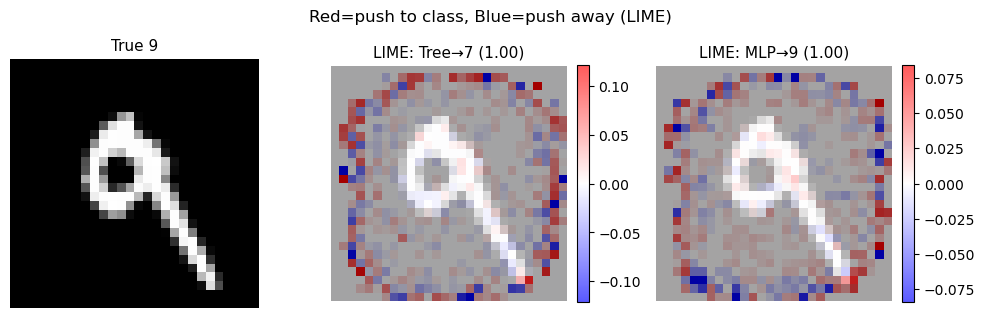


Example idx=8: true=5, Tree→8 (1.000), MLP→5 (1.000)


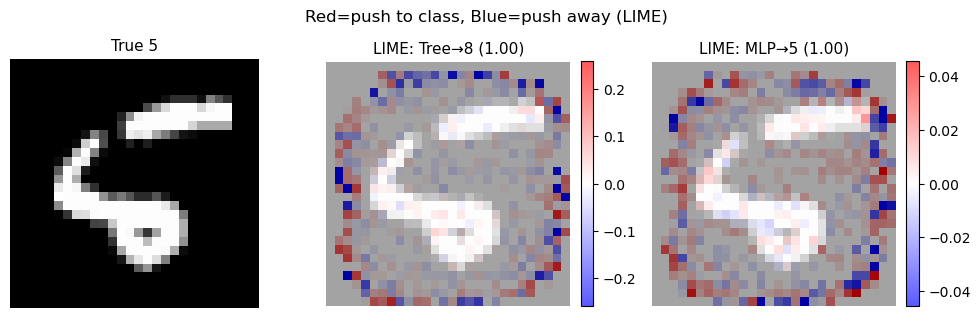


Example idx=54: true=6, Tree→8 (1.000), MLP→6 (1.000)


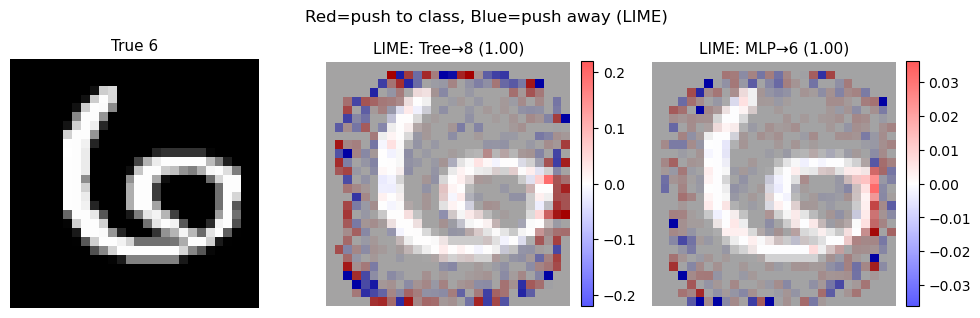

In [6]:
# Visual, audience-friendly explanations for MNIST:
# - Trains DecisionTree and MLP
# - Finds examples where MLP is correct and Tree is wrong
# - Shows the image plus LIME overlays (and optional SHAP) for both models
# - Red = pushes toward predicted class; Blue = pushes away

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# Optional explainers
try:
    from lime.lime_tabular import LimeTabularExplainer
    HAS_LIME = True
except Exception:
    HAS_LIME = False

try:
    import shap
    HAS_SHAP = True
except Exception:
    HAS_SHAP = False

# Toggles
DO_LIME = True
DO_SHAP = False  # Turn on to add SHAP overlays (slower)

def dense_lime_vector(exp, label, n_features):
    vec = np.zeros(n_features, dtype=float)
    for j, w in exp.local_exp[label]:
        vec[int(j)] = float(w)
    return vec

def contrib_map_from_vector(vec, clip_percentile=99.0):
    # Map per-feature contribution vector to 28x28 image, with symmetric clipping for robust color scaling
    m = vec.reshape(28, 28)
    vmax = np.percentile(np.abs(m), clip_percentile)
    return m, float(vmax if vmax > 0 else np.max(np.abs(m)) + 1e-12)

def show_triptych(x_img, tree_map, mlp_map, vmax_tree, vmax_mlp, title_left, title_mid, title_right, suptitle=None):
    fig, axes = plt.subplots(1, 3, figsize=(10, 3.2))
    # Original
    axes[0].imshow(x_img, cmap="gray", interpolation="nearest")
    axes[0].set_title(title_left, fontsize=11)
    axes[0].axis("off")
    # Tree + LIME overlay
    axes[1].imshow(x_img, cmap="gray", interpolation="nearest")
    im1 = axes[1].imshow(tree_map, cmap="bwr", alpha=0.65, vmin=-vmax_tree, vmax=vmax_tree, interpolation="nearest")
    axes[1].set_title(title_mid, fontsize=11)
    axes[1].axis("off")
    plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
    # MLP + LIME overlay
    axes[2].imshow(x_img, cmap="gray", interpolation="nearest")
    im2 = axes[2].imshow(mlp_map, cmap="bwr", alpha=0.65, vmin=-vmax_mlp, vmax=vmax_mlp, interpolation="nearest")
    axes[2].set_title(title_right, fontsize=11)
    axes[2].axis("off")
    plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)
    if suptitle:
        fig.suptitle(suptitle, fontsize=12)
    plt.tight_layout()
    plt.show()

def show_triptych_shap(x_img, tree_map, mlp_map, vmax_tree, vmax_mlp, title_left, title_mid, title_right, suptitle=None):
    # Same visualization but labeled for SHAP
    show_triptych(x_img, tree_map, mlp_map, vmax_tree, vmax_mlp, title_left, title_mid, title_right, suptitle)

def main():
    # Load MNIST
    mnist = fetch_openml(name="mnist_784", version=1, as_frame=False, parser="auto")
    X = mnist.data
    y = mnist.target.astype(int)

    # Split (first 60k train, last 10k test)
    X_train, X_test = X[:60000], X[60000:]
    y_train, y_test = y[:60000], y[60000:]

    # Models
    tree = DecisionTreeClassifier(random_state=42)
    mlp  = MLPClassifier(random_state=42)

    # Train
    tree.fit(X_train, y_train)
    mlp.fit(X_train, y_train)

    # Evaluate
    y_pred_tree = tree.predict(X_test)
    y_pred_mlp  = mlp.predict(X_test)
    acc_tree = accuracy_score(y_test, y_pred_tree)
    acc_mlp  = accuracy_score(y_test, y_pred_mlp)
    print(f"DecisionTree accuracy: {acc_tree:.4f}")
    print(f"MLP accuracy:         {acc_mlp:.4f}")

    # Choose examples where MLP is correct and Tree is wrong (fallback to random)
    mask = (y_pred_mlp == y_test) & (y_pred_tree != y_test)
    idxs = np.where(mask)[0]
    if idxs.size == 0:
        rng = np.random.RandomState(123)
        idxs = rng.choice(X_test.shape[0], size=min(3, X_test.shape[0]), replace=False)
        print("\nNo (MLP correct, Tree wrong) cases found; showing random examples.")
    else:
        idxs = idxs[:3]
        print(f"\nShowing {len(idxs)} example(s) where MLP is correct and Tree is wrong:")

    # Prepare LIME
    feature_names = [f"pixel_{i}" for i in range(X.shape[1])]
    class_names = [str(c) for c in range(10)]
    lime_explainer = None
    if DO_LIME and HAS_LIME:
        rng = np.random.RandomState(42)
        subset = rng.choice(X_train.shape[0], size=min(5000, X_train.shape[0]), replace=False)
        lime_explainer = LimeTabularExplainer(
            training_data=X_train[subset],
            mode="classification",
            feature_names=feature_names,
            class_names=class_names,
            discretize_continuous=True,
            random_state=42
        )
    elif DO_LIME:
        print("LIME not installed. Install with: pip install lime")

    # SHAP background
    shap_background = None
    if DO_SHAP and HAS_SHAP:
        rng = np.random.RandomState(42)
        shap_background = X_train[rng.choice(X_train.shape[0], size=min(200, X_train.shape[0]), replace=False)]
    elif DO_SHAP:
        print("SHAP not installed. Install with: pip install shap")

    # Visualize selected examples
    for idx in idxs:
        x0 = X_test[idx:idx+1]
        x_img = x0.reshape(28, 28)
        y_true = int(y_test[idx])

        proba_tree = tree.predict_proba(x0)[0]
        proba_mlp  = mlp.predict_proba(x0)[0]
        pred_tree  = int(np.argmax(proba_tree))
        pred_mlp   = int(np.argmax(proba_mlp))

        print(f"\nExample idx={idx}: true={y_true}, Tree→{pred_tree} ({proba_tree[pred_tree]:.3f}), MLP→{pred_mlp} ({proba_mlp[pred_mlp]:.3f})")

        # LIME overlays
        if DO_LIME and HAS_LIME:
            # Use a relatively large num_features so the heatmap is informative but still fast
            exp_tree = lime_explainer.explain_instance(
                data_row=x0[0],
                predict_fn=tree.predict_proba,
                num_features=400,
                top_labels=1
            )
            exp_mlp = lime_explainer.explain_instance(
                data_row=x0[0],
                predict_fn=mlp.predict_proba,
                num_features=400,
                top_labels=1
            )
            vec_tree = dense_lime_vector(exp_tree, pred_tree, X.shape[1])
            vec_mlp  = dense_lime_vector(exp_mlp,  pred_mlp,  X.shape[1])

            map_tree, vmax_tree = contrib_map_from_vector(vec_tree)
            map_mlp,  vmax_mlp  = contrib_map_from_vector(vec_mlp)

            title_left  = f"True {y_true}"
            title_mid   = f"Tree→{pred_tree} ({proba_tree[pred_tree]:.2f})"
            title_right = f"MLP→{pred_mlp} ({proba_mlp[pred_mlp]:.2f})"
            show_triptych(
                x_img, map_tree, map_mlp, vmax_tree, vmax_mlp,
                title_left, "LIME: " + title_mid, "LIME: " + title_right,
                suptitle="Red=push to class, Blue=push away (LIME)"
            )
        else:
            print("Skipping LIME overlays (not enabled or not installed).")

        # Optional SHAP overlays for corroboration
        if DO_SHAP and HAS_SHAP:
            expl_tree = shap.KernelExplainer(model=tree.predict_proba, data=shap_background, link="logit")
            expl_mlp  = shap.KernelExplainer(model=mlp.predict_proba,  data=shap_background, link="logit")
            sv_tree = expl_tree.shap_values(x0, nsamples=100)  # list per class
            sv_mlp  = expl_mlp.shap_values(x0,  nsamples=100)
            vec_tree_s = sv_tree[pred_tree][0]
            vec_mlp_s  = sv_mlp[pred_mlp][0]

            map_tree_s, vmax_tree_s = contrib_map_from_vector(vec_tree_s)
            map_mlp_s,  vmax_mlp_s  = contrib_map_from_vector(vec_mlp_s)

            title_left  = f"True {y_true}"
            title_mid   = f"Tree→{pred_tree} ({proba_tree[pred_tree]:.2f})"
            title_right = f"MLP→{pred_mlp} ({proba_mlp[pred_mlp]:.2f})"
            show_triptych_shap(
                x_img, map_tree_s, map_mlp_s, vmax_tree_s, vmax_mlp_s,
                title_left, "SHAP: " + title_mid, "SHAP: " + title_right,
                suptitle="Red=push to class, Blue=push away (SHAP)"
            )

if __name__ == "__main__":
    main()


How to interpret colors quickly
Red pixels increase the predicted class score for that model and instance, and blue pixels decrease it; this is exactly how LIME’s local surrogate weights and Kernel SHAP’s additive attributions are meant to be read for a given prediction.​

MLP panels typically show red contributions tracing coherent strokes of the true digit, while the tree often highlights isolated pixels because it splits along single features; this visual difference explains the higher MLP accuracy you observed.​


In [10]:
!pip install -U scipy scikit-image
import scipy, skimage
print("SciPy:", scipy.__version__)
print("scikit-image:", skimage.__version__)


SciPy: 1.11.1
scikit-image: 0.25.2


In [11]:
# MNIST: Visual explanations that clearly contrast DecisionTree vs MLP
# - Trains both models.
# - Finds examples where MLP is correct and Tree is wrong.
# - For each example, shows:
#   Row 1: Original | Occlusion(Tree) | Occlusion(MLP) | Occlusion(MLP-Tree)
#   Row 2: LIME(Tree superpixels) | LIME(MLP superpixels) | LIME(MLP-Tree difference)
#
# Requirements: pip install lime scikit-image matplotlib
# LIME image explainer uses superpixels (quickshift by default) and returns per-segment weights.

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# LIME (image)
from lime.lime_image import LimeImageExplainer
from skimage.segmentation import slic
from skimage.segmentation import mark_boundaries

# ---------- Helpers ----------

def to_rgb(img28):
    # Convert 28x28 grayscale to 28x28x3 RGB for LIME image explainer
    if img28.ndim == 2:
        return np.stack([img28, img28, img28], axis=-1)
    if img28.shape[-1] == 1:
        return np.repeat(img28, 3, axis=-1)
    return img28

def batch_predict_for_lime(model):
    # Wrap scikit-learn predict_proba to accept a list/array of 28x28x3 images
    def _predict(images):
        # images: iterable of HxWx3 arrays
        X = np.array([img[..., 0].reshape(1, -1) for img in images])  # take one channel; shape (N,1,784)
        X = X[:, 0, :]  # -> (N, 784)
        return model.predict_proba(X)
    return _predict

def occlusion_map(model, x_img, window=5, stride=3, occlude_value=0.0):
    """
    Compute occlusion sensitivity: drop in predicted prob for the predicted class when masking patches.
    Returns a 28x28 heatmap with per-pixel aggregated drops.
    """
    H, W = x_img.shape
    base_proba = model.predict_proba(x_img.reshape(1, -1))[0]
    pred_label = int(np.argmax(base_proba))
    base_score = float(base_proba[pred_label])
    heat = np.zeros((H, W), dtype=float)
    counts = np.zeros((H, W), dtype=float)

    for r in range(0, H - window + 1, stride):
        for c in range(0, W - window + 1, stride):
            x_occ = x_img.copy()
            x_occ[r:r+window, c:c+window] = occlude_value
            pr = model.predict_proba(x_occ.reshape(1, -1))[0][pred_label]
            drop = max(0.0, base_score - float(pr))
            heat[r:r+window, c:c+window] += drop
            counts[r:r+window, c:c+window] += 1.0

    counts[counts == 0] = 1.0
    heat /= counts
    return heat, pred_label, base_score

def lime_superpixel_map(explainer, model, x_img, num_features=10, num_samples=1000):
    """
    Build a per-pixel heatmap from superpixel weights:
    - positive values push toward the predicted class
    - negative values push away
    """
    rgb = to_rgb(x_img)
    exp = explainer.explain_instance(
        image=rgb,
        classifier_fn=batch_predict_for_lime(model),
        top_labels=1,
        num_samples=num_samples
    )
    pred_label = exp.top_labels[0]
    # segments used by LIME (superpixels)
    segments = exp.segments
    # weights per superpixel for the predicted label (list of (sp_idx, weight))
    weights = dict(exp.local_exp[pred_label])

    heat = np.zeros_like(x_img, dtype=float)
    for sp_idx, w in weights.items():
        heat[segments == sp_idx] = w
    return heat, pred_label

def symmetric_limits(*arrays, percentile=99.0):
    vmax = max(np.percentile(np.abs(a), percentile) for a in arrays if a is not None)
    return (-vmax, vmax) if vmax > 0 else (-1.0, 1.0)

def show_grid(fig_title, x_img, occ_tree, occ_mlp, lime_tree, lime_mlp,
              title_info_tree, title_info_mlp):
    # Compute difference maps
    occ_diff = occ_mlp - occ_tree
    lime_diff = lime_mlp - lime_tree

    # Color limits
    vmin_occ, vmax_occ = 0.0, np.percentile(np.r_[occ_tree.ravel(), occ_mlp.ravel()], 99.0)
    vmin_lime, vmax_lime = symmetric_limits(lime_tree, lime_mlp, percentile=99.0)
    vmin_diff_lime, vmax_diff_lime = symmetric_limits(lime_diff, percentile=99.0)
    vmin_diff_occ, vmax_diff_occ = symmetric_limits(occ_diff, percentile=99.0)

    fig, axes = plt.subplots(2, 4, figsize=(13, 6))
    # Row 1
    axes[0,0].imshow(x_img, cmap="gray")
    axes[0,0].set_title("Original")
    axes[0,0].axis("off")

    im = axes[0,1].imshow(occ_tree, cmap="hot", vmin=vmin_occ, vmax=vmax_occ)
    axes[0,1].set_title(f"Occlusion Tree\n{title_info_tree}")
    axes[0,1].axis("off"); plt.colorbar(im, ax=axes[0,1], fraction=0.046, pad=0.03)

    im = axes[0,2].imshow(occ_mlp, cmap="hot", vmin=vmin_occ, vmax=vmax_occ)
    axes[0,2].set_title(f"Occlusion MLP\n{title_info_mlp}")
    axes[0,2].axis("off"); plt.colorbar(im, ax=axes[0,2], fraction=0.046, pad=0.03)

    im = axes[0,3].imshow(occ_diff, cmap="bwr", vmin=vmin_diff_occ, vmax=vmax_diff_occ)
    axes[0,3].set_title("Occlusion Δ (MLP − Tree)")
    axes[0,3].axis("off"); plt.colorbar(im, ax=axes[0,3], fraction=0.046, pad=0.03)

    # Row 2
    axes[1,0].imshow(x_img, cmap="gray")
    axes[1,0].set_title("Original")
    axes[1,0].axis("off")

    im = axes[1,1].imshow(lime_tree, cmap="bwr", vmin=vmin_lime, vmax=vmax_lime)
    axes[1,1].set_title("LIME Tree (superpixels)")
    axes[1,1].axis("off"); plt.colorbar(im, ax=axes[1,1], fraction=0.046, pad=0.03)

    im = axes[1,2].imshow(lime_mlp, cmap="bwr", vmin=vmin_lime, vmax=vmax_lime)
    axes[1,2].set_title("LIME MLP (superpixels)")
    axes[1,2].axis("off"); plt.colorbar(im, ax=axes[1,2], fraction=0.046, pad=0.03)

    im = axes[1,3].imshow(lime_diff, cmap="bwr", vmin=vmin_diff_lime, vmax=vmax_diff_lime)
    axes[1,3].set_title("LIME Δ (MLP − Tree)")
    axes[1,3].axis("off"); plt.colorbar(im, ax=axes[1,3], fraction=0.046, pad=0.03)

    fig.suptitle(fig_title, fontsize=12)
    plt.tight_layout()
    plt.show()

def main():
    # Load MNIST
    mnist = fetch_openml(name="mnist_784", version=1, as_frame=False, parser="auto")
    X = mnist.data
    y = mnist.target.astype(int)

    # Split
    X_train, X_test = X[:60000], X[60000:]
    y_train, y_test = y[:60000], y[60000:]

    # Models
    tree = DecisionTreeClassifier(random_state=42)
    mlp  = MLPClassifier(random_state=42)

    # Train
    tree.fit(X_train, y_train)
    mlp.fit(X_train, y_train)

    # Accuracy
    y_pred_tree = tree.predict(X_test)
    y_pred_mlp  = mlp.predict(X_test)
    acc_tree = accuracy_score(y_test, y_pred_tree)
    acc_mlp  = accuracy_score(y_test, y_pred_mlp)
    print(f"DecisionTree accuracy: {acc_tree:.4f}")
    print(f"MLP accuracy:         {acc_mlp:.4f}")

    # Pick examples where MLP is correct and Tree is wrong (or fallback)
    mask = (y_pred_mlp == y_test) & (y_pred_tree != y_test)
    idxs = np.where(mask)[0]
    if idxs.size == 0:
        rng = np.random.RandomState(123)
        idxs = rng.choice(X_test.shape[0], size=min(3, X_test.shape[0]), replace=False)
        print("\nNo (MLP correct, Tree wrong) cases found; showing random examples.")
    else:
        idxs = idxs[:3]
        print(f"\nShowing {len(idxs)} example(s) where MLP is correct and Tree is wrong:")

    # LIME image explainer (superpixels)
    explainer = LimeImageExplainer(random_state=42)

    for idx in idxs:
        x0 = X_test[idx].reshape(28, 28)
        y_true = int(y_test[idx])
        p_tree = tree.predict_proba(x0.reshape(1, -1))[0]
        p_mlp  = mlp.predict_proba(x0.reshape(1, -1))[0]
        pred_tree, conf_tree = int(np.argmax(p_tree)), float(p_tree.max())
        pred_mlp,  conf_mlp  = int(np.argmax(p_mlp)),  float(p_mlp.max())
        print(f"\nExample idx={idx}: true={y_true}, Tree→{pred_tree} ({conf_tree:.3f}), MLP→{pred_mlp} ({conf_mlp:.3f})")

        # Occlusion maps
        occ_tree, _, _ = occlusion_map(tree, x0, window=5, stride=3, occlude_value=0.0)
        occ_mlp,  _, _ = occlusion_map(mlp,  x0, window=5, stride=3, occlude_value=0.0)

        # LIME superpixel maps (signed; red pushes toward predicted class)
        lime_tree, _ = lime_superpixel_map(explainer, tree, x0, num_features=10, num_samples=1000)
        lime_mlp,  _ = lime_superpixel_map(explainer, mlp,  x0, num_features=10, num_samples=1000)

        title_tree = f"Tree→{pred_tree} ({conf_tree:.2f})"
        title_mlp  = f"MLP→{pred_mlp} ({conf_mlp:.2f})"
        show_grid(
            fig_title=f"Idx {idx} | True {y_true}",
            x_img=x0,
            occ_tree=occ_tree, occ_mlp=occ_mlp,
            lime_tree=lime_tree, lime_mlp=lime_mlp,
            title_info_tree=title_tree,
            title_info_mlp=title_mlp
        )

if __name__ == "__main__":
    main()


ImportError: cannot import name '_transition_to_rng' from 'scipy._lib._util' (/home/saurabh-singh/miniconda3/envs/mlenv/lib/python3.11/site-packages/scipy/_lib/_util.py)